<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/14_DropOut_demo1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [51]:
# Generate Data

x_train = np.linspace(-1,1,20)

y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])


In [52]:
x_test = np.linspace(-1, 1, 20)
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

<function matplotlib.pyplot.show(close=None, block=None)>

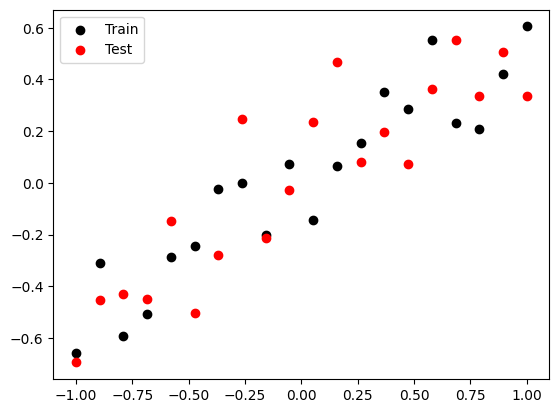

In [53]:
plt.scatter(x_train,y_train,c='black',label = "Train")
plt.scatter(x_test,y_test,c='red',label = "Test")
plt.legend()
plt.show

# Regression Model


In [54]:
from sklearn.utils import validation
from sklearn import metrics
model_1 = Sequential()

model_1.add(Dense(128,input_dim = 1 , activation = 'relu'))
model_1.add(Dense(128 , activation = 'relu'))
model_1.add(Dense(1, activation = 'linear'))

adam = Adam(learning_rate=0.01)
model_1.compile(loss= 'mse',optimizer = adam,metrics = ['mse'])

history = model_1.fit(x_train , y_train , epochs = 500 , validation_data = (x_test,y_test),verbose = False)


In [55]:
# evaluate the model

_, train_mse = model_1.evaluate(x_train, y_train, verbose=0)
_, test_mse = model_1.evaluate(x_test, y_test, verbose=0)
print('Train: {}, Test: {}'.format(train_mse, test_mse))

Train: 0.009924429468810558, Test: 0.03685194253921509


In [56]:
y_pred_1 = model_1.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


Checking Overfitting :

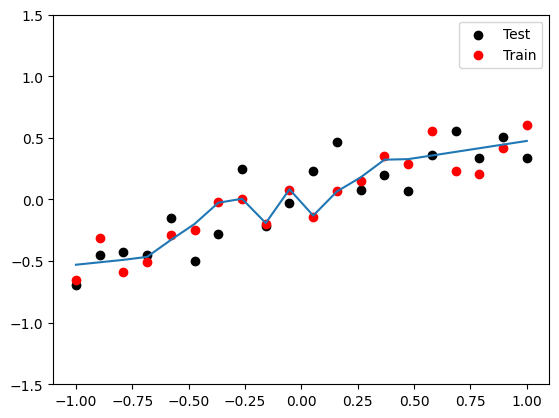

In [57]:
plt.figure()
plt.scatter(x_test,y_test,c ='black',label="Test")
plt.scatter(x_train,y_train,c="red",label="Train")
plt.plot(x_test,y_pred_1)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

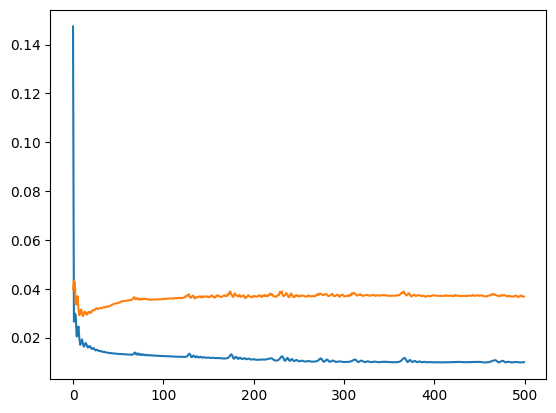

In [58]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

# DropOut Model : Reducing Overfitting

In [59]:
model = Sequential()

model.add(Dense(128,input_dim = 1 , activation = 'relu'))
model.add(Dropout(0.2))

model.add(Dense(128 , activation = 'relu'))
model.add(Dropout(0.2))

model.add(Dense(1, activation = 'linear'))

adam = Adam(learning_rate=0.01)
model.compile(loss= 'mse',optimizer = adam,metrics = ['mse'])

history = model.fit(x_train , y_train , epochs = 500 , validation_data = (x_test,y_test),verbose = False)

In [60]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,693 (198.02 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 33,796 (132.02 KB)

In [61]:
# Evaluate the model

_, train_mse = model.evaluate(x_train,y_train,verbose=0)
_, test_mse = model.evaluate(x_test,y_test,verbose =0)
print(f"Train : {train_mse} , Test : {test_mse}")

Train : 0.011735832318663597 , Test : 0.035770706832408905


In [62]:
y_pred = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


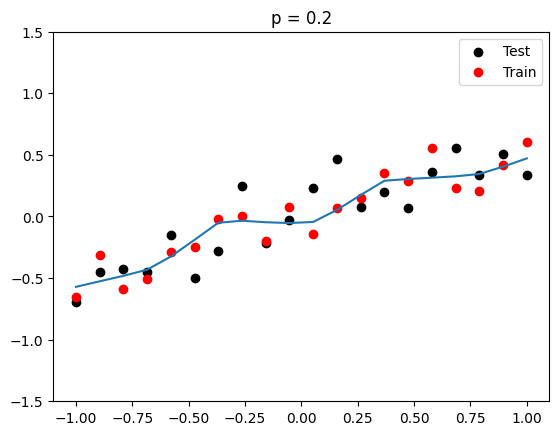

In [63]:
plt.figure()
plt.title("p = 0.2")
plt.scatter(x_test,y_test,c ='black',label="Test")
plt.scatter(x_train,y_train,c="red",label="Train")
plt.plot(x_test,y_pred)
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

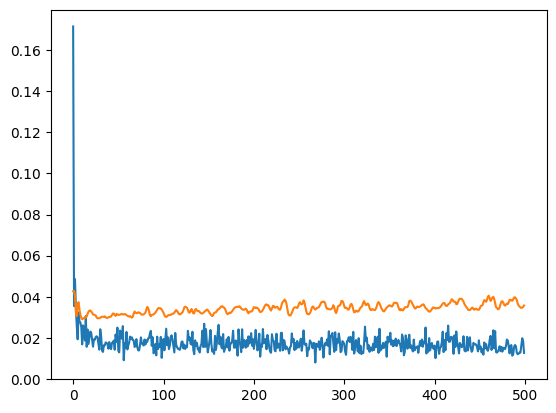

In [64]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])